In [1]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.utils as utils
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import sys
import matplotlib.pyplot as plt
import numpy as np
import math
from torchvision.models import vgg16

In [2]:
def visualize_filters(weights, layer_name):
    weights = weights.cpu().detach()
    if weights.shape[1] == 3:
        weights = weights
    else: # for layers with more than 3 channels, take only the first 3 channels
        weights = weights[:, :3, :, :] 
    f_min = weights.min()
    f_max = weights.max()
    weights = (weights - f_min) / (f_max - f_min)

    grid = utils.make_grid(weights, nrow=8, padding=1, normalize=False)
    np_grid = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(12, 12))
    plt.imshow(np_grid)
    plt.axis('off')
    plt.title(f'Filters of Layer: {layer_name}')
    plt.show()



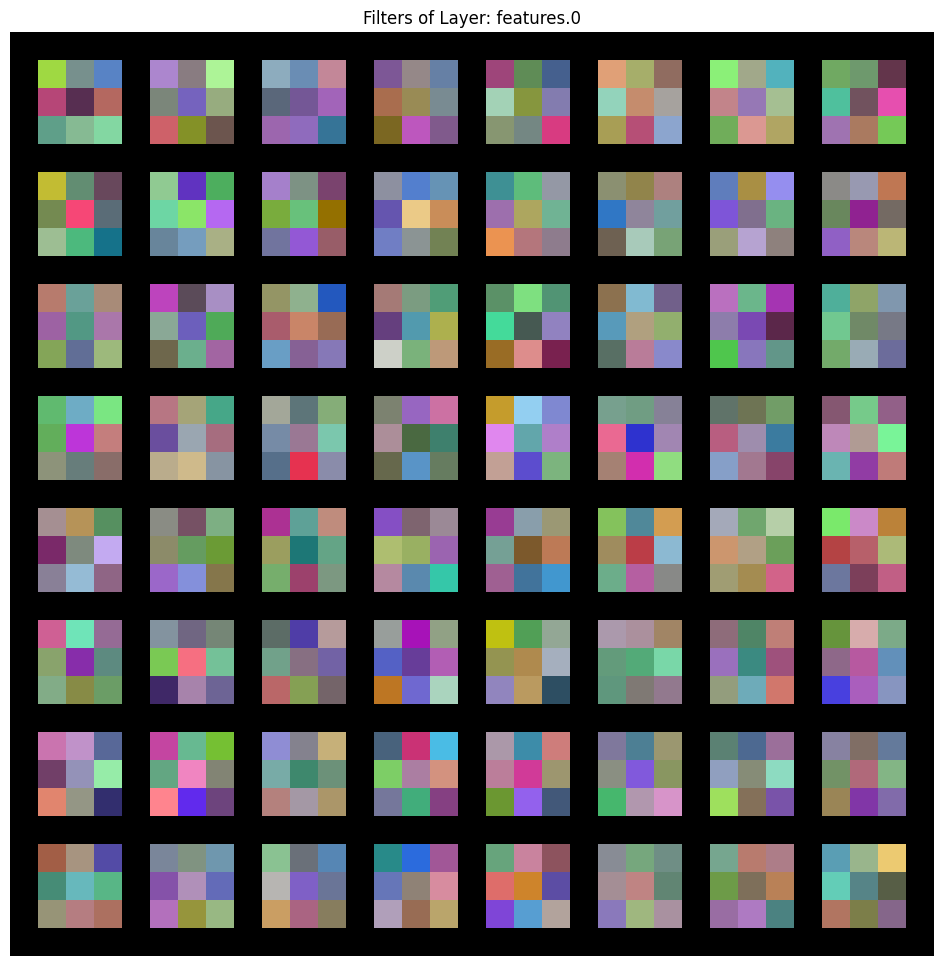

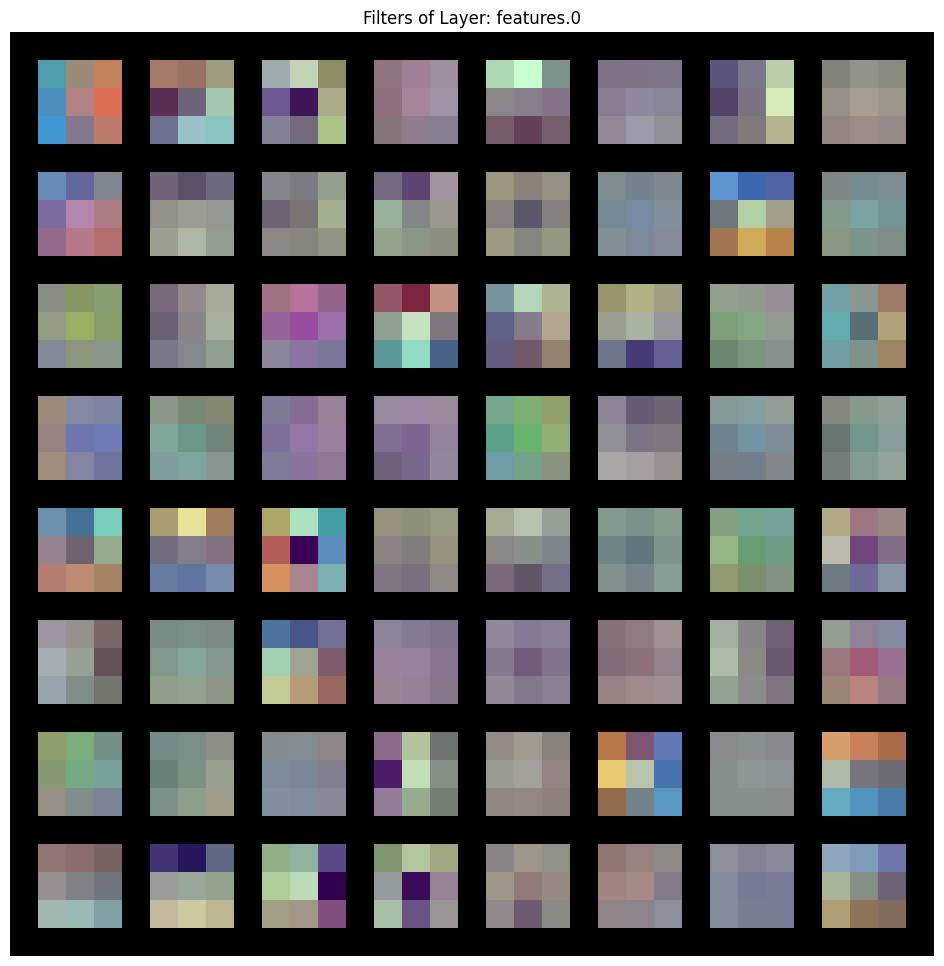

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [116]:
# vgg16 
transform = transforms.Compose([
    # transforms.Resize(228),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

dataset1 = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataset2 = datasets.CIFAR10(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset1)
test_loader = torch.utils.data.DataLoader(dataset2)

model = models.vgg16()
visualize_filters(model.features[0].weight.data, 'features.0')

# # Visualize filters of all conv layers
# for name, module in model.named_modules():
#     if isinstance(module, nn.Conv2d):
#         weights = module.weight.data
#         print(f"\n Conv Layer: {name} | Shape: {weights.shape}")        
#         # if 'features.0' in name or 'features.2' in name or 'features.5' in name:
#         visualize_filters(weights, name)

model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
visualize_filters(model.features[0].weight.data, 'features.0')

num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 10)

model.eval()


In [5]:
import torchinfo

model_v = models.vgg19()
batch_size = 16
torchinfo.summary(model_v, input_size = (batch_size, 3, 210, 210))


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [16, 1000]                --
├─Sequential: 1-1                        [16, 512, 6, 6]           --
│    └─Conv2d: 2-1                       [16, 64, 210, 210]        1,792
│    └─ReLU: 2-2                         [16, 64, 210, 210]        --
│    └─Conv2d: 2-3                       [16, 64, 210, 210]        36,928
│    └─ReLU: 2-4                         [16, 64, 210, 210]        --
│    └─MaxPool2d: 2-5                    [16, 64, 105, 105]        --
│    └─Conv2d: 2-6                       [16, 128, 105, 105]       73,856
│    └─ReLU: 2-7                         [16, 128, 105, 105]       --
│    └─Conv2d: 2-8                       [16, 128, 105, 105]       147,584
│    └─ReLU: 2-9                         [16, 128, 105, 105]       --
│    └─MaxPool2d: 2-10                   [16, 128, 52, 52]         --
│    └─Conv2d: 2-11                      [16, 256, 52, 52]         29

In [6]:
import torchsummary
from torchsummary import summary
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,


 Conv Layer: features.0 | Shape: torch.Size([64, 3, 3, 3])


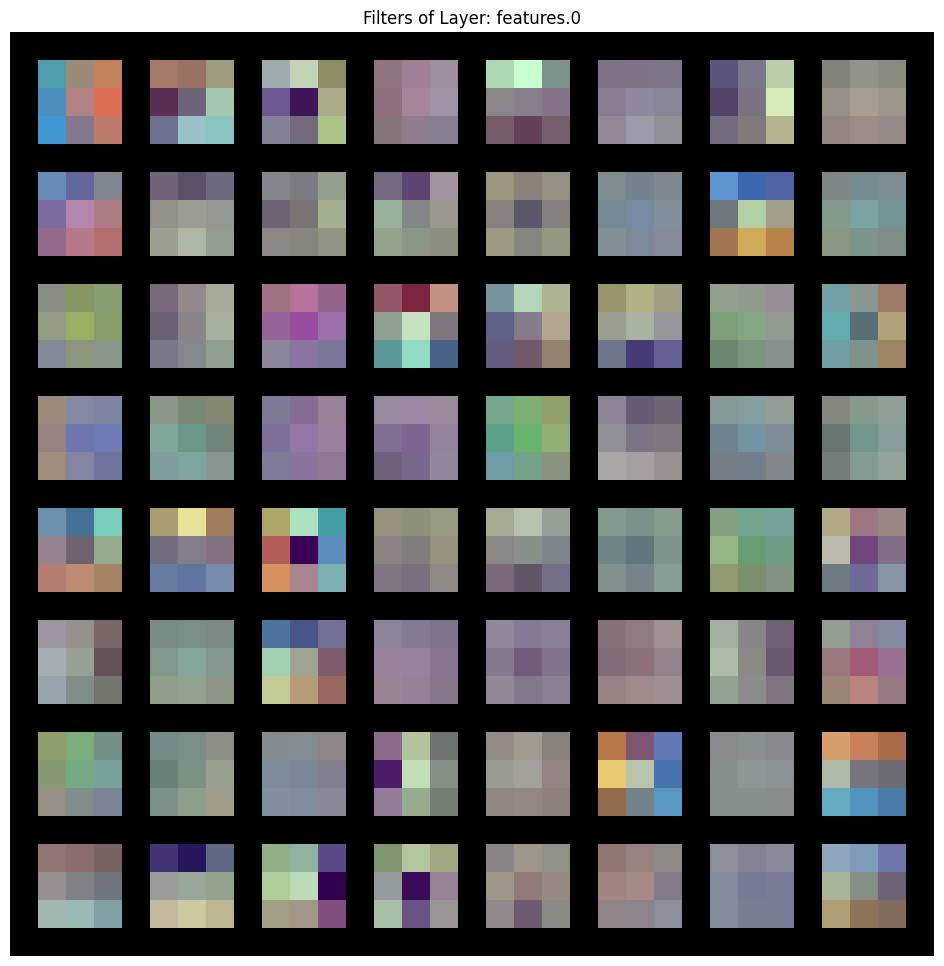


 Conv Layer: features.2 | Shape: torch.Size([64, 64, 3, 3])


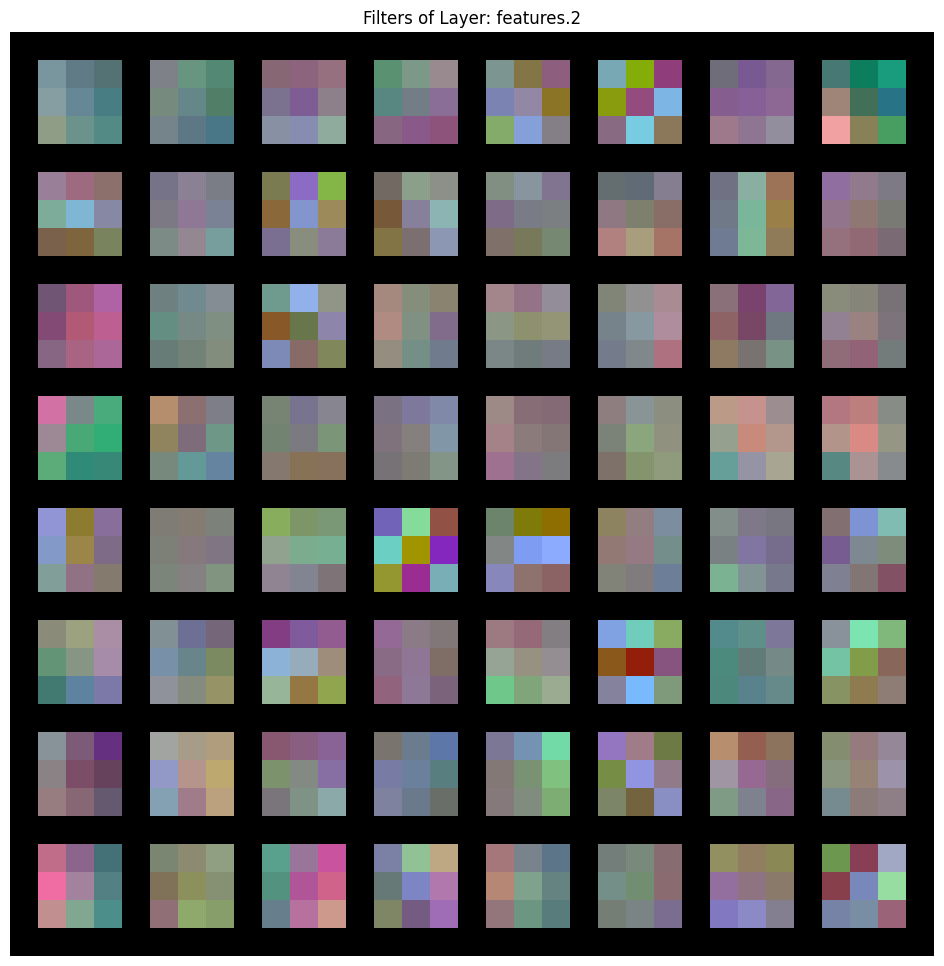


 Conv Layer: features.5 | Shape: torch.Size([128, 64, 3, 3])


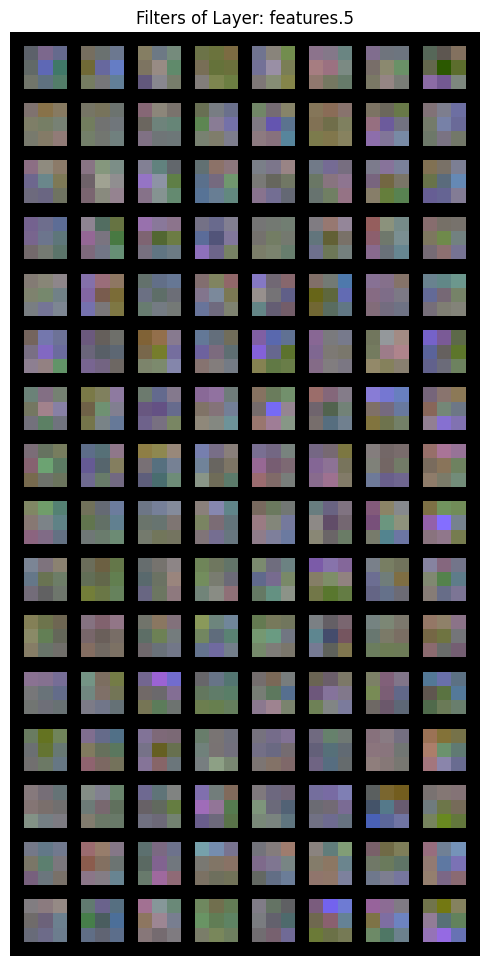


 Conv Layer: features.7 | Shape: torch.Size([128, 128, 3, 3])


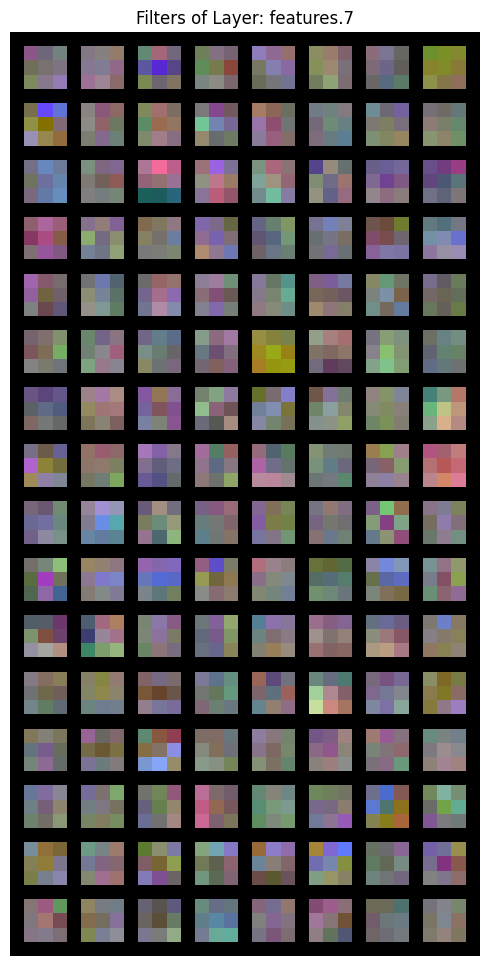


 Conv Layer: features.10 | Shape: torch.Size([256, 128, 3, 3])


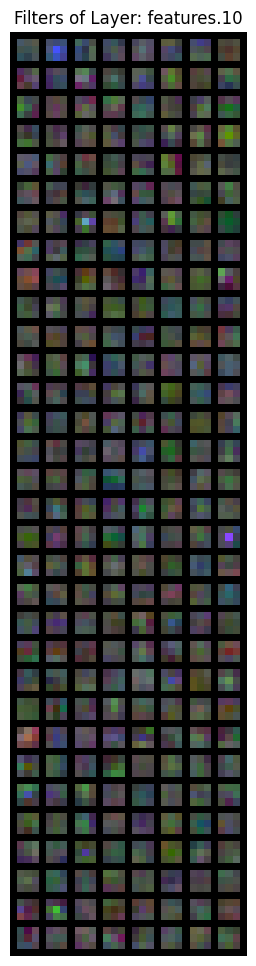


 Conv Layer: features.12 | Shape: torch.Size([256, 256, 3, 3])


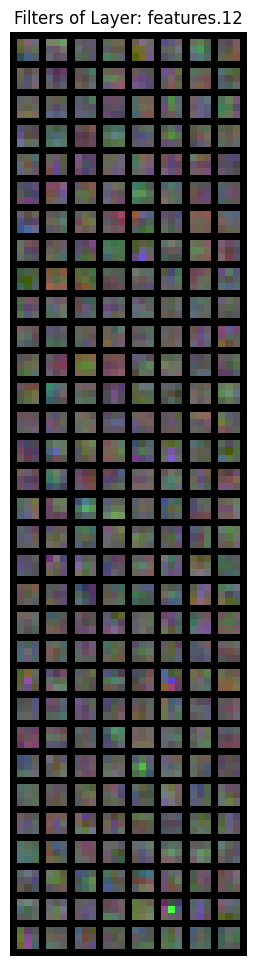


 Conv Layer: features.14 | Shape: torch.Size([256, 256, 3, 3])


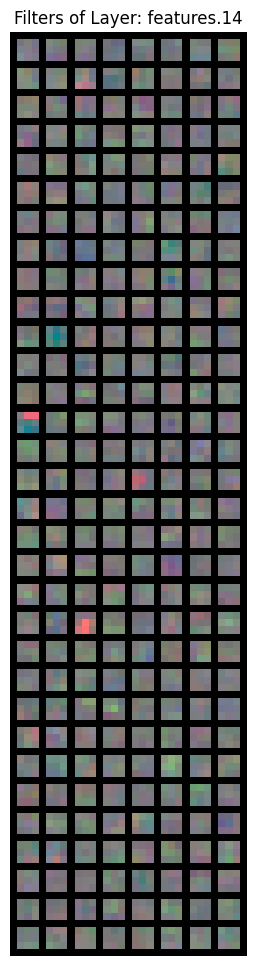


 Conv Layer: features.17 | Shape: torch.Size([512, 256, 3, 3])


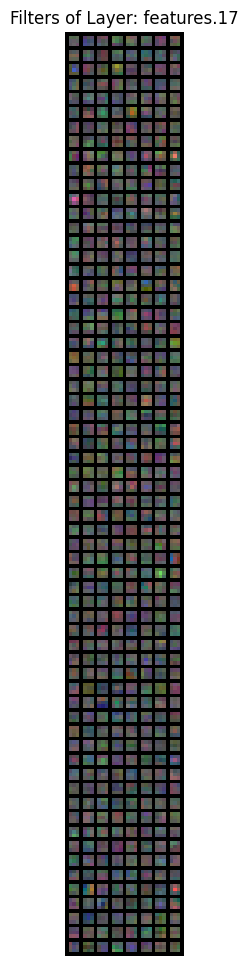


 Conv Layer: features.19 | Shape: torch.Size([512, 512, 3, 3])


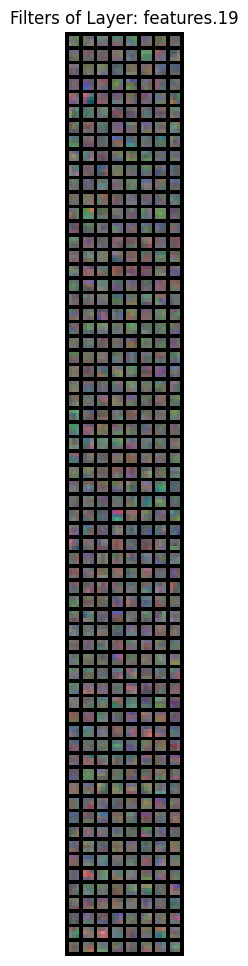


 Conv Layer: features.21 | Shape: torch.Size([512, 512, 3, 3])


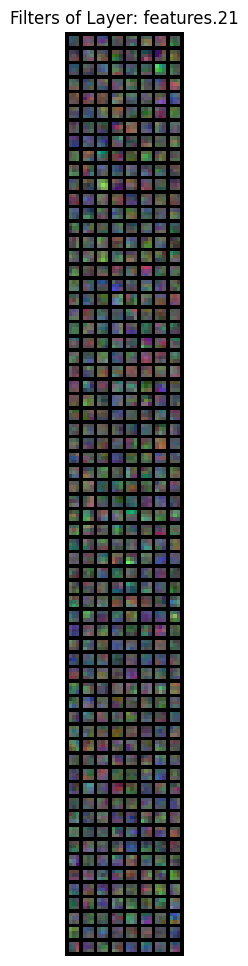


 Conv Layer: features.24 | Shape: torch.Size([512, 512, 3, 3])


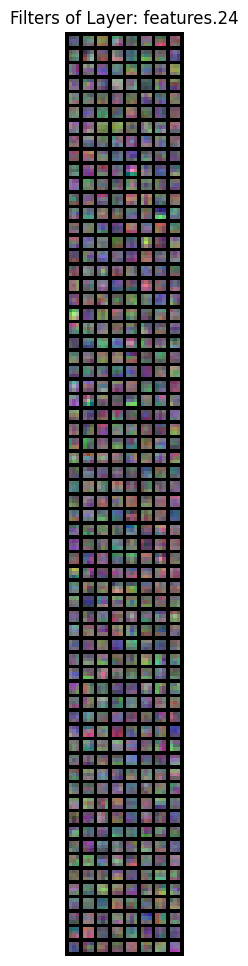


 Conv Layer: features.26 | Shape: torch.Size([512, 512, 3, 3])


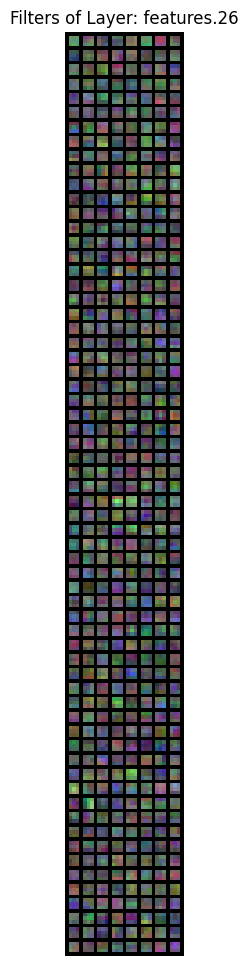


 Conv Layer: features.28 | Shape: torch.Size([512, 512, 3, 3])


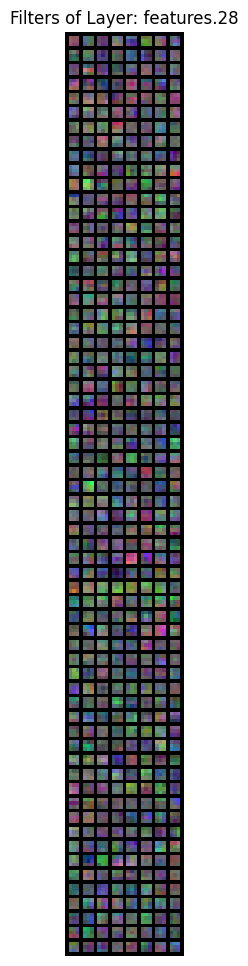

In [10]:
# Visualize filters of all conv layers
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        weights = module.weight.data
        print(f"\n Conv Layer: {name} | Shape: {weights.shape}")        
        # if 'features.0' in name or 'features.2' in name or 'features.5' in name:
        visualize_filters(weights, name)




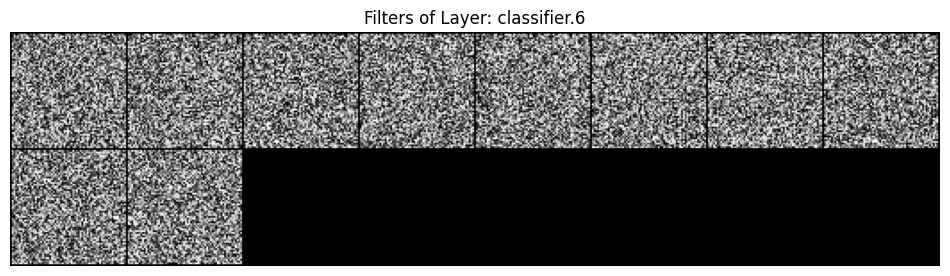

In [7]:
# visualize the weights of the last fully connected layer as 10 images of 64x64
fc_weights = model.classifier[6].weight.data  # shape: [10, 4096]
fc_weights_reshaped = fc_weights.view(10, 1, 64, 64)  # reshape to [10, 1, 64, 64]
visualize_filters(fc_weights_reshaped, 'classifier.6')

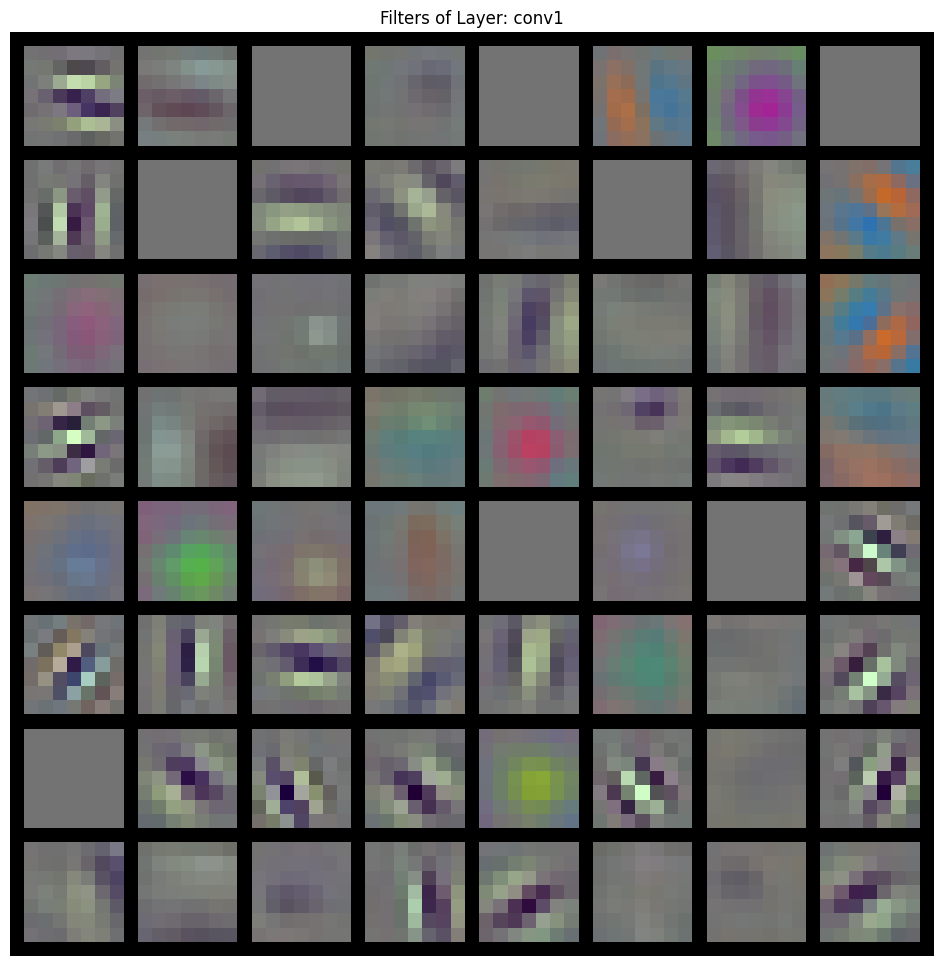

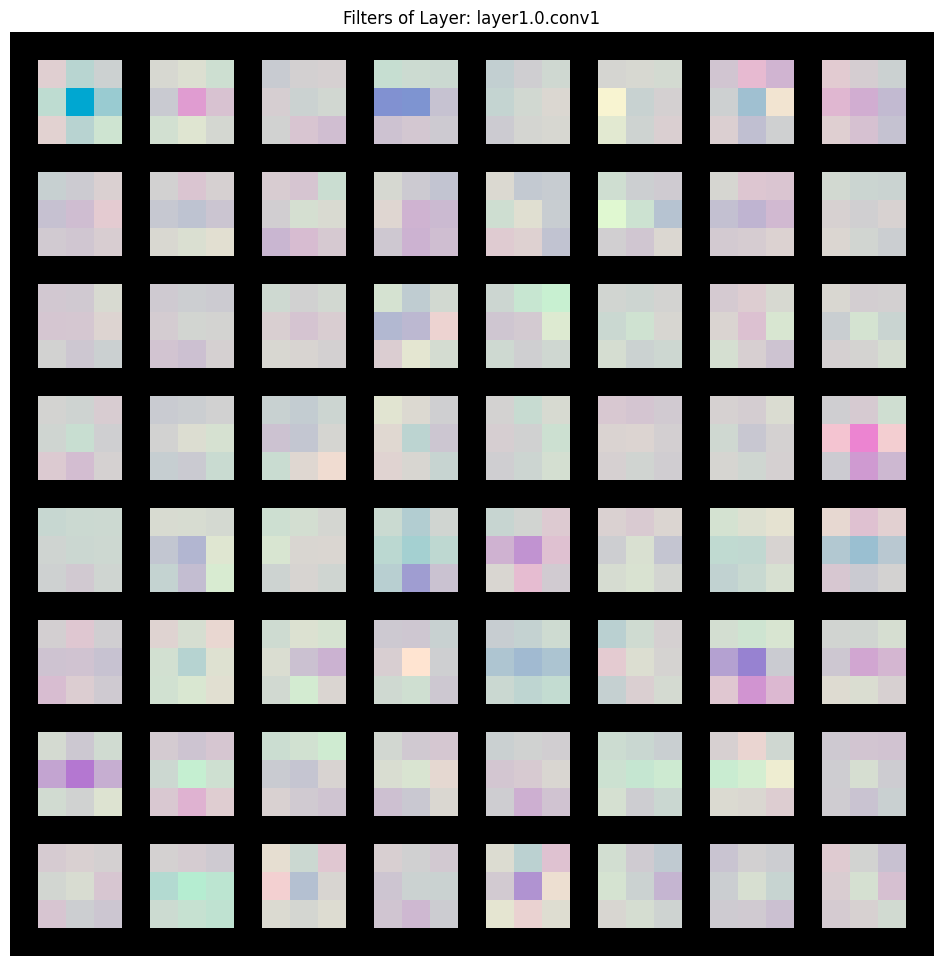

In [147]:
# resnet18

model_rn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
visualize_filters(model_rn.conv1.weight.data, 'conv1')
visualize_filters(model_rn.layer1[0].conv1.weight.data, 'layer1.0.conv1')
# visualize_filters(model_rn.layer[].weight.data, 'conv2')

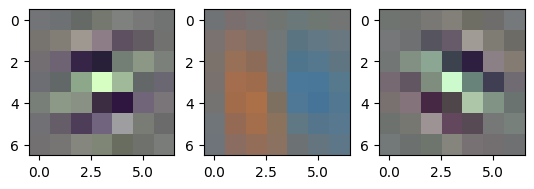

In [110]:
weights = model_rn.conv1.weight.data
weights = weights.cpu().detach()
weights_norm = weights - weights.min()
weights_norm = weights_norm / weights_norm.max()
plt.subplot(131)
w1_t = weights[24].unsqueeze(0)
w1 = weights_norm[24].permute(1,2,0).numpy()
plt.imshow(w1)
plt.subplot(132)
w2_t = weights[5].unsqueeze(0)
w2 = weights_norm[5].permute(1,2,0).numpy()
plt.imshow(w2)
plt.subplot(133)
w3_t = weights[39].unsqueeze(0)
w3 = weights_norm[39].permute(1,2,0).numpy()
plt.imshow(w3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


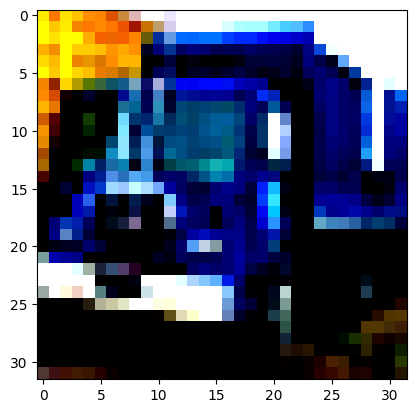

In [111]:
# get one image from the test dataset
img_t = dataset2[14
        ][0].unsqueeze(0)  
img = img_t[0].permute(1,2,0).numpy()
plt.imshow(img)

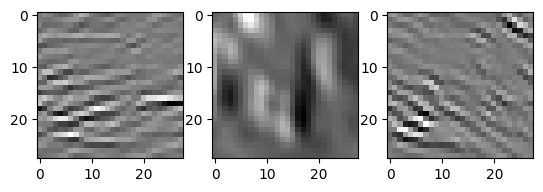

In [114]:
# applying w1 as filter to img using convolution
import torch.nn.functional as F

plt.subplot(131)
conv_img1 = F.conv2d(img_t, w1_t, padding=1)
conv_img1 = conv_img1[0, 0].detach().numpy()
plt.imshow(conv_img1, cmap="gray")
plt.subplot(132)
conv_img2 = F.conv2d(img_t, w2_t, padding=1)
conv_img2 = conv_img2[0, 0].detach().numpy()
plt.imshow(conv_img2, cmap="gray")
plt.subplot(133)
conv_img3 = F.conv2d(img_t, w3_t, padding=1)
conv_img3 = conv_img3[0, 0].detach().numpy()
plt.imshow(conv_img3, cmap="gray")

In [52]:
model_rn.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [55]:
summary(model_rn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [58]:
from torchinfo import summary
batch_size = 16
summary(model_rn, input_size= (batch_size,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [16, 1000]                --
├─Conv2d: 1-1                            [16, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [16, 64, 112, 112]        128
├─ReLU: 1-3                              [16, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [16, 64, 56, 56]          --
├─Sequential: 1-5                        [16, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [16, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [16, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [16, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [16, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [16, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [16, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [16, 64, 56, 56]          --
│

In [ ]:
# testing the accuracy of model_rn on cifar10 test set
test(model_rn, torch.device('cpu'), test_loader) 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.5546865].


Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Activations shape after conv1: torch.Size([10, 64, 112, 112])


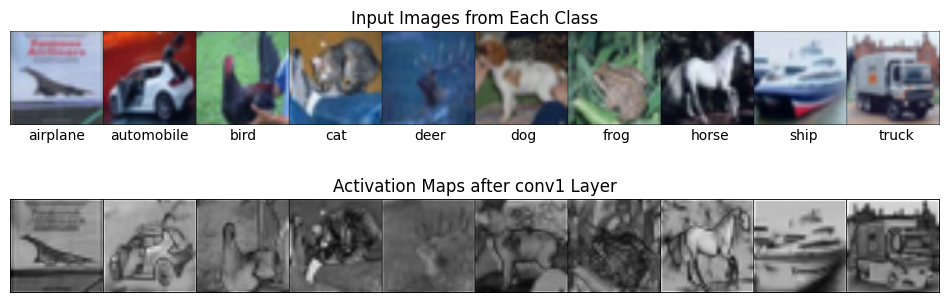

In [50]:
# store 1 image from each class

class_names = dataset2.classes
print(f'Class names: {class_names}')
class_images = []
for i in range(10):
    for img, label in dataset2:
        if label == i:
            class_images.append(img)
            break
class_images = torch.stack(class_images)  # shape: [10, 3, 224, 224]

# show the images and their activation maps after passing through conv1 layer
model_rn.eval()
with torch.no_grad():
    
    # show all 10 class images in one row, with their activations maps below them
    grid = utils.make_grid(class_images, nrow=10, padding=1, normalize=True)
    np_grid = grid.permute(1, 2, 0).numpy() # convert to HWC for matplotlib
    plt.figure(figsize=(12, 4))
    plt.subplot(2, 1, 1)
    plt.imshow(np_grid)
    plt.axis('off')
    plt.title('Input Images from Each Class')
    for i in range(10):
        plt.text(i * (224 + 2) + 112, 224 + 10, class_names[i], ha='center', va='top', fontsize=10)

    activations = model_rn.conv1(class_images)  # shape: [10, 64, H, W]
    activations = F.relu(activations)
    # print shape of activations
    print(f'Activations shape after conv1: {activations.shape}') # torch.Size([10, 64, 112, 112])
    # reshape activations to (10, H, W, C) for visualization
    activations = activations.permute(0, 2, 3, 1)  # shape: [10, 112, 112, 64]
    # different ways to visualize 64-channel activations
    activations_mean = activations.mean(dim=-1, keepdim=True)  # shape: [10, 112, 112, 1]
    activations_rgb = activations[:, :, :, :3]  # take first 3 channels as RGB, shape: [10, 112, 112, 3]
    plt.subplot(2, 1, 2)
    activation_grid = utils.make_grid(activations_mean.permute(0, 3, 1, 2), nrow=10, padding=1) # permute to (C, H, W)
    np_activation_grid = activation_grid.permute(1, 2, 0).numpy()
    plt.imshow(np_activation_grid, cmap='viridis')
    plt.axis('off')
    plt.title('Activation Maps after conv1 Layer')
    plt.show()

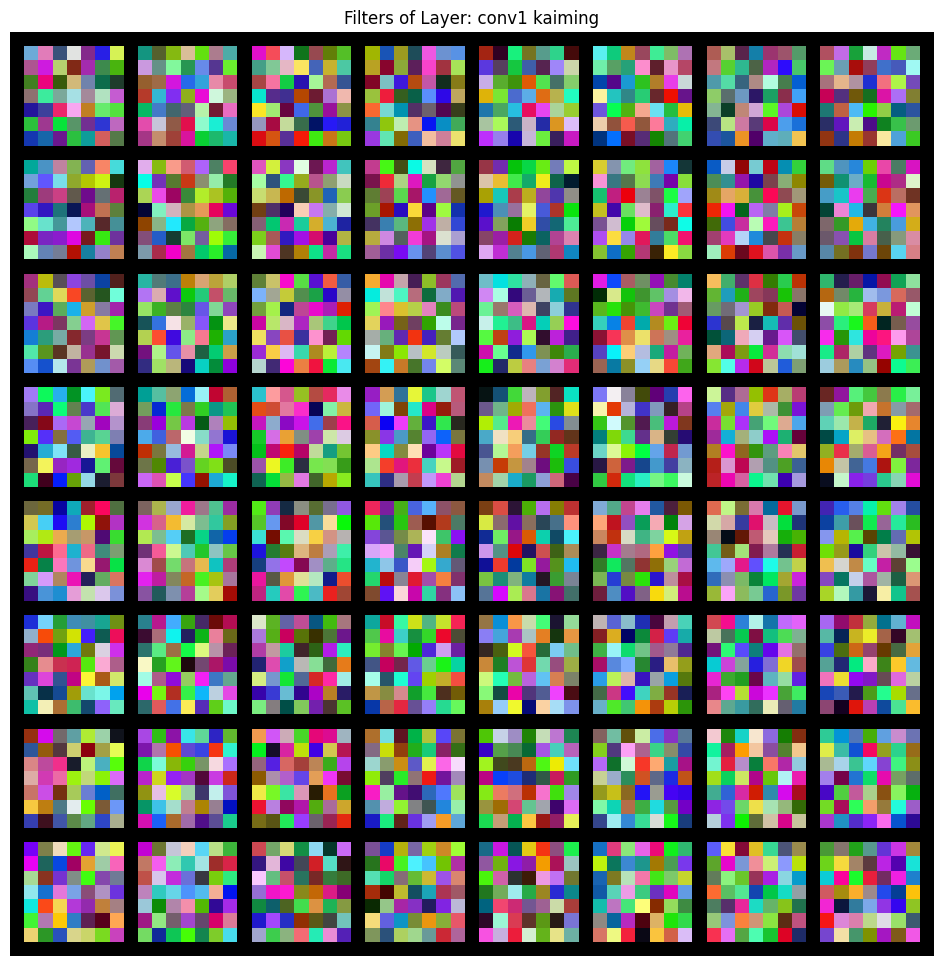

In [140]:
model_rn_kaiming = models.resnet18(weights=None)
model_rn_kaiming.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=1, bias=False)
model_rn_kaiming.maxpool = nn.Identity()
model_rn_kaiming.fc = nn.Linear(512, 10)
model_rn_kaiming = model_rn_kaiming.to(torch.device('cpu'))

visualize_filters(model_rn_kaiming.conv1.weight.detach(), 'conv1 kaiming')

In [134]:
def train(model, dataloader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = 100.0 * correct / total

    return avg_loss, accuracy


In [133]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            test_loss += F.cross_entropy(
                output, target, reduction='sum'
            ).item()

            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)

    print(
        f"\nTest set: Average loss: {test_loss:.4f}, "
        f"Accuracy: {correct}/{len(test_loader.dataset)} ({acc:.2f}%)\n"
    )

    return test_loss, acc

In [143]:
def main():

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader = torch.utils.data.DataLoader(
        dataset1, batch_size=128, shuffle=True
    )
    test_loader = torch.utils.data.DataLoader(
        dataset2, batch_size=256, shuffle=False
    )

    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(
        3, 64, kernel_size=7, stride=1, padding=3, bias=False
    )
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, 10)
    model = model.to(device)
    visualize_filters(model.conv1.weight.detach(),"conv1_epoch_0")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4
    )
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=30, gamma=0.1
    )

    num_epochs = 5
    for epoch in range(1, num_epochs + 1):
        _, train_acc = train(
            model, train_loader, optimizer, criterion, device
        )

        _, test_acc = test(
            model, device, test_loader
        )

        scheduler.step()

        print(
            f"Epoch {epoch:03d} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Acc: {test_acc:.2f}%"
        )

        # Visualize filters every epoch
        visualize_filters(
            model.conv1.weight.detach(),
            f"conv1_epoch_{epoch}"
        )



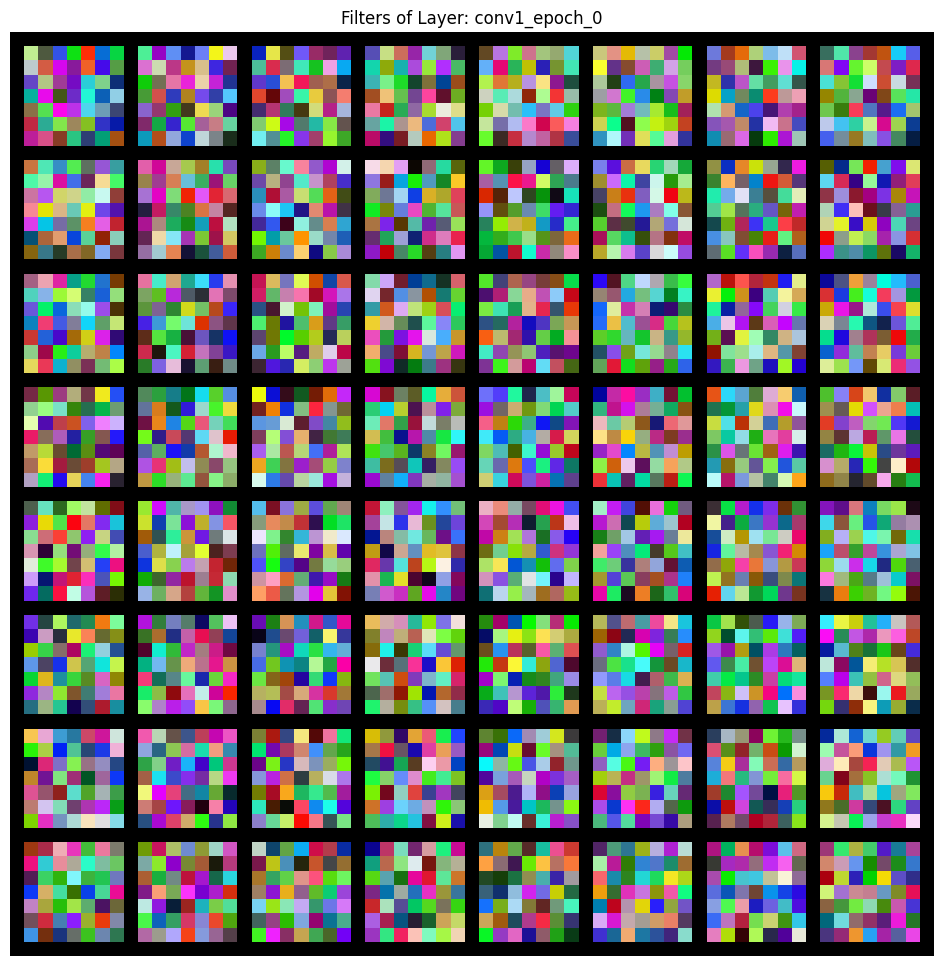


Test set: Average loss: 1.4012, Accuracy: 4811/10000 (48.11%)

Epoch 001 | Train Acc: 34.32% | Test Acc: 48.11%


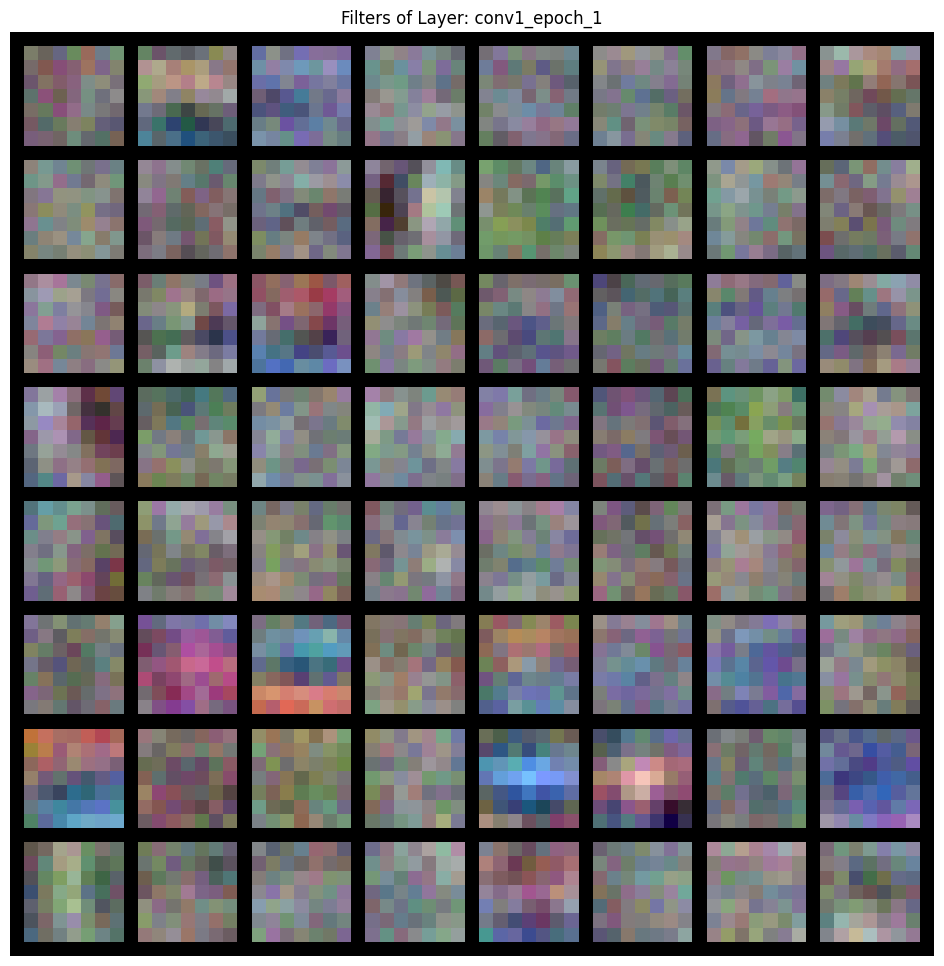


Test set: Average loss: 1.1356, Accuracy: 5957/10000 (59.57%)

Epoch 002 | Train Acc: 54.50% | Test Acc: 59.57%


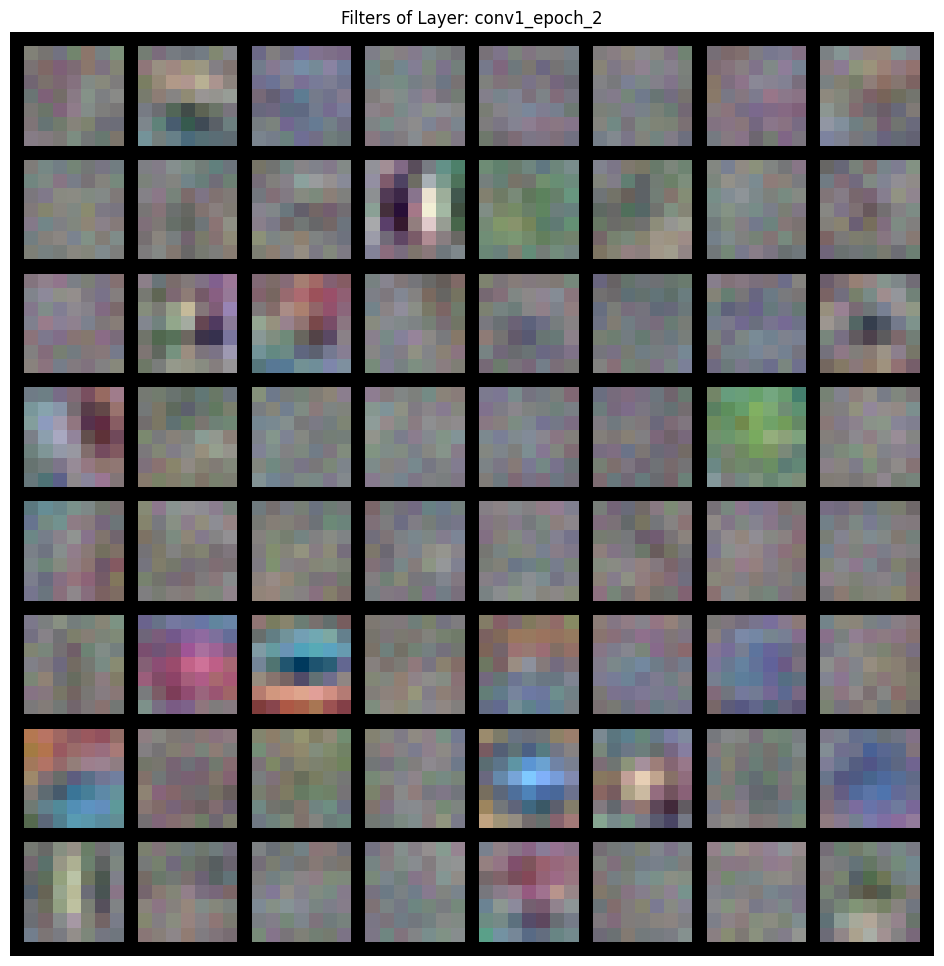


Test set: Average loss: 0.9355, Accuracy: 6758/10000 (67.58%)

Epoch 003 | Train Acc: 66.71% | Test Acc: 67.58%


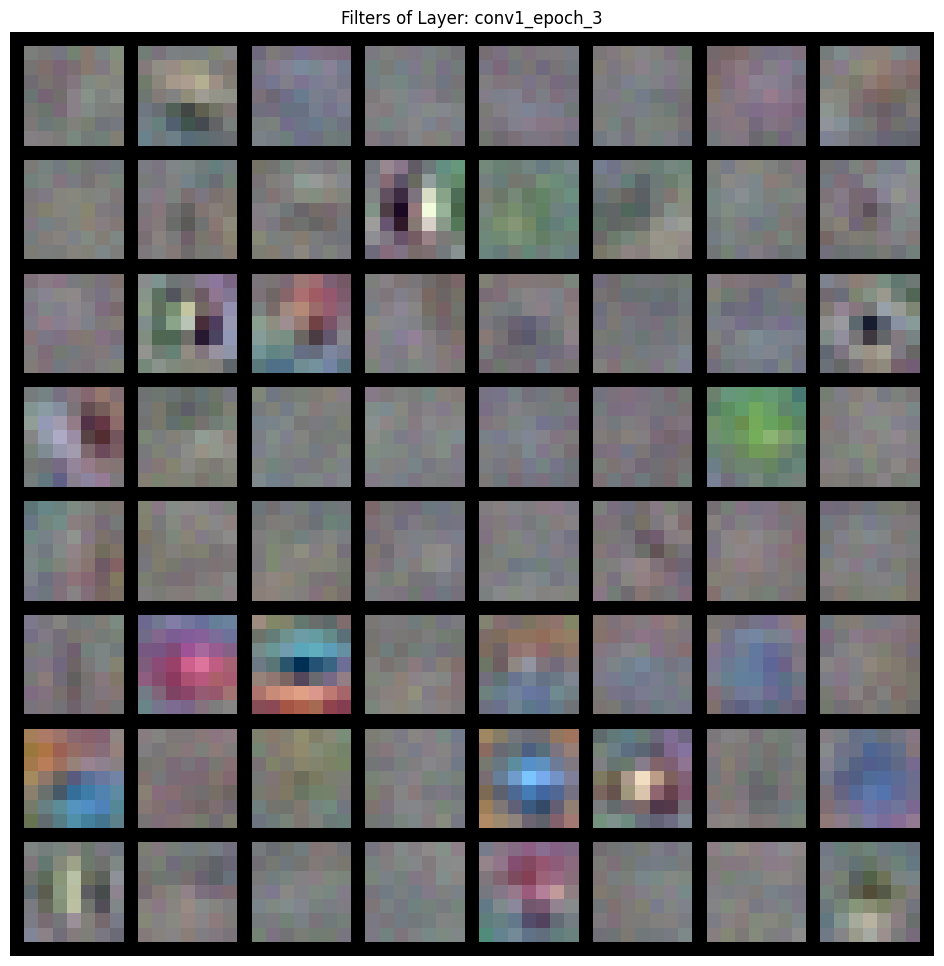

KeyboardInterrupt: 

In [144]:
main()